# Problema 10.3(i): simulación del sistema truncado a dos modos

Integramos el sistema de amplitudes de Kuramoto–Sivashinsky hasta
$$
t_f=4,
$$
con la condición inicial
$$
(a_1(0),a_2(0))=(1,0),
$$
para los valores
$$
\frac{1}{k}=\frac{L}{2\pi}=0.8,\;1.2,\;1.94.
$$


## Sistema de dos modos

Partimos del sistema modal
$$
\dot a_\ell=(1-k^2\ell^2)\ell^2a_\ell
-\frac{1}{2}\sum_{m=1}^{\infty}m a_m
\left[\operatorname{sg}(\ell-m)a_{|\ell-m|}+a_{\ell+m}\right].
$$

Al truncar en dos modos imponemos
$$
a_j=0\qquad \text{para }j>2.
$$

Para el primer modo se obtiene
$$
\dot a_1=(1-k^2)a_1+\frac{1}{2}a_1a_2,
$$
y para el segundo,
$$
\dot a_2=(4-16k^2)a_2-\frac{1}{2}a_1^2.
$$

Para conservar la notación del análisis de puntos fijos, mantenemos
$$
k
$$
como parámetro de las ecuaciones. En el código se ingresan los valores pedidos de
$$
\frac{1}{k}=\frac{L}{2\pi}
$$
y se toma su inversa para obtener el parámetro `k`.

Los puntos fijos obtenidos en el inciso anterior son
$$
P_0=(0,0)
$$
y
$$
P_{\pm}=\left(\pm4\sqrt{(k^2-1)(1-4k^2)},\;2(k^2-1)\right).
$$
El radicando es no negativo para
$$
\frac{1}{2}\leq |k|\leq 1.
$$
Los puntos son distintos del origen en el intervalo estricto. Como en este problema se considera `k > 0` y
$$
k=\frac{2\pi}{L},
$$
esto equivale a
$$
\frac{1}{2}<k<1
\quad\Longleftrightarrow\quad
1<\frac{1}{k}=\frac{L}{2\pi}<2
\quad\Longleftrightarrow\quad
2\pi<L<4\pi.
$$


## Reducción explícita de la suma no lineal

La truncación a dos modos significa que solamente conservamos `a_1` y `a_2`. Por lo tanto,
$$
a_0=0,
\qquad
a_j=0\quad\text{si}\quad j>2.
$$

Para el modo `1`, los únicos aportes posibles de la suma corresponden a `m=1` y `m=2`. El término con `m=1` produce `a_1a_2`, mientras que el término con `m=2` produce `-2a_1a_2`. Entonces,
$$
-\frac{1}{2}\left(a_1a_2-2a_1a_2\right)
=\frac{1}{2}a_1a_2.
$$

Para el modo `2`, solamente sobrevive el producto entre dos amplitudes del primer modo:
$$
-\frac{1}{2}a_1^2.
$$

De esta manera se obtiene el sistema cerrado
$$
\boxed{
\begin{aligned}
\dot a_1&=(1-k^2)a_1+\frac{1}{2}a_1a_2,\\
\dot a_2&=4(1-4k^2)a_2-\frac{1}{2}a_1^2.
\end{aligned}}
$$

Los primeros términos de ambas ecuaciones describen el crecimiento o amortiguamiento lineal de cada modo. Los términos cuadráticos representan el intercambio no lineal entre ellos. En particular, aunque inicialmente `a_2(0)=0`, se cumple
$$
\dot a_2(0)=-\frac{1}{2}a_1(0)^2=-\frac{1}{2},
$$
por lo que el segundo modo aparece inmediatamente y toma valores negativos.

Además, la primera ecuación puede factorizarse como
$$
\dot a_1=a_1\left(1-k^2+\frac{a_2}{2}\right).
$$
Como partimos de `a_1(0)=1`, la trayectoria permanece en el semiplano de amplitud `a_1` positiva. Por eso, cuando existen dos puntos fijos simétricos, la solución se relaciona con la rama positiva `P_+`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})


In [2]:
def rhs_dos_modos(a, inverso_k):
    """Derivada temporal para el truncamiento de Galerkin con N=2."""
    a1, a2 = a
    k = 1.0 / inverso_k

    da1 = (1.0 - k**2) * a1 + 0.5 * a1 * a2
    da2 = (4.0 - 16.0 * k**2) * a2 - 0.5 * a1**2

    return np.array([da1, da2], dtype=float)


## Integración temporal

Aplicamos el método clásico de Runge–Kutta de cuarto orden. Para un estado
$$
\mathbf a_n=(a_{1,n},a_{2,n}),
$$
calculamos cuatro estimaciones de la pendiente:
$$
\begin{aligned}
\mathbf K_1&=\mathbf F(\mathbf a_n),\\
\mathbf K_2&=\mathbf F\left(\mathbf a_n+\frac{\Delta t}{2}\mathbf K_1\right),\\
\mathbf K_3&=\mathbf F\left(\mathbf a_n+\frac{\Delta t}{2}\mathbf K_2\right),\\
\mathbf K_4&=\mathbf F\left(\mathbf a_n+\Delta t\,\mathbf K_3\right).
\end{aligned}
$$

El nuevo estado se obtiene mediante el promedio ponderado
$$
\mathbf a_{n+1}=\mathbf a_n+
\frac{\Delta t}{6}\left(\mathbf K_1+2\mathbf K_2+2\mathbf K_3+\mathbf K_4\right).
$$

Tomamos un paso temporal
$$
\Delta t=10^{-3}.
$$
Con este valor se realizan `4000` pasos hasta llegar a `t_f=4`. Para controlar que el resultado no dependa del paso elegido, repetimos el cálculo con
$$
\Delta t=5\times10^{-4}
$$
y comparamos los estados finales. Una diferencia muy pequeña entre ambas integraciones indica convergencia temporal.


In [3]:
def integrar_rk4(inverso_k, tf=4.0, dt=1.0e-3, a0=(1.0, 0.0)):
    """Integra el sistema autónomo mediante RK4."""
    n_steps = int(np.ceil(tf / dt))
    dt = tf / n_steps

    t = np.linspace(0.0, tf, n_steps + 1)
    a = np.empty((n_steps + 1, 2), dtype=float)
    a[0] = a0

    for n in range(n_steps):
        an = a[n]
        k1 = rhs_dos_modos(an, inverso_k)
        k2 = rhs_dos_modos(an + 0.5 * dt * k1, inverso_k)
        k3 = rhs_dos_modos(an + 0.5 * dt * k2, inverso_k)
        k4 = rhs_dos_modos(an + dt * k3, inverso_k)

        a[n + 1] = an + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return t, a


def punto_fijo_positivo(inverso_k):
    """Rama P_+ de los puntos fijos no triviales, cuando es real."""
    k = 1.0 / inverso_k
    radicando = (k**2 - 1.0) * (1.0 - 4.0 * k**2)
    if radicando < 0.0:
        return None
    return np.array([4.0*np.sqrt(radicando), 2.0*(k**2 - 1.0)])


In [4]:
valores_inverso_k = (0.8, 1.2, 1.94)
resultados = {}

print("  1/k      k        a1(4)         a2(4)       error al refinar dt")
for inverso_k in valores_inverso_k:
    t, a = integrar_rk4(inverso_k, dt=1.0e-3)
    _, a_fino = integrar_rk4(inverso_k, dt=5.0e-4)
    error = np.linalg.norm(a[-1] - a_fino[-1], ord=np.inf)
    resultados[inverso_k] = (t, a)
    print(f" {inverso_k:4.2f}  {1/inverso_k:7.5f}  {a[-1,0]: .9f}   {a[-1,1]: .9f}      {error:.3e}")


  1/k      k        a1(4)         a2(4)       error al refinar dt
 0.80  1.25000   0.104313397   -0.000273747      7.966e-16
 1.20  0.83333   2.319668316   -0.365045343      5.773e-15
 1.94  0.51546   0.679143475   -2.239417542      2.709e-14


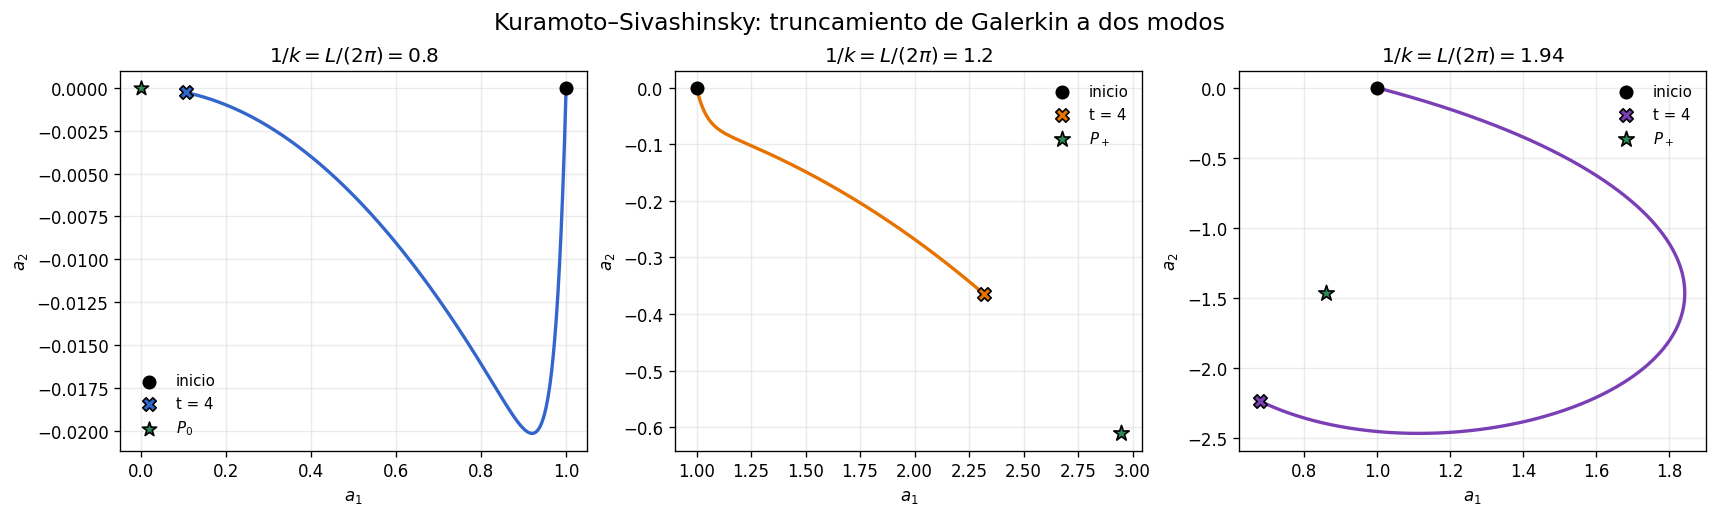

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.2), constrained_layout=True)
colores = ("#3366CC", "#E67300", "#7B3FB5")

for ax, color, inverso_k in zip(axes, colores, valores_inverso_k):
    _, a = resultados[inverso_k]
    ax.plot(a[:, 0], a[:, 1], color=color, lw=2)
    ax.scatter(*a[0], s=55, color="black", label="inicio", zorder=3)
    ax.scatter(*a[-1], s=65, color=color, edgecolor="black",
               marker="X", label="t = 4", zorder=3)
    punto = punto_fijo_positivo(inverso_k)
    if punto is not None:
        ax.scatter(*punto, s=95, color="#2E8B57", edgecolor="black",
                   marker="*", label=r"$P_+$", zorder=4)
    else:
        ax.scatter(0.0, 0.0, s=80, color="#2E8B57", edgecolor="black",
                   marker="*", label=r"$P_0$", zorder=4)
    ax.set_title(rf"$1/k=L/(2\pi)={inverso_k}$")
    ax.set_xlabel(r"$a_1$")
    ax.set_ylabel(r"$a_2$")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle("Kuramoto–Sivashinsky: truncamiento de Galerkin a dos modos", fontsize=14)
plt.show()


## Lectura dinámica de los tres casos

La estrella verde indica el punto fijo relevante para la condición inicial elegida. El marcador negro representa el estado inicial y la cruz señala la posición alcanzada en `t=4`.

### Caso `1/k = 0.8`

En este caso `k=1.25`. Los autovalores del origen son
$$
\lambda_1=1-k^2=-0.5625,
\qquad
\lambda_2=4(1-4k^2)=-21.
$$
Ambos son negativos, de modo que el origen `P_0` es estable. La amplitud `a_2` primero se vuelve negativa por el acoplamiento cuadrático, pero luego ambos modos se amortiguan y la trayectoria regresa al origen.

### Caso `1/k = 1.2`

Aquí `k=0.83333`. El origen tiene una dirección inestable porque
$$
\lambda_1=1-k^2>0.
$$
La rama positiva del punto fijo no trivial es aproximadamente
$$
P_+=(2.948111,-0.611111).
$$
Este punto es un nodo estable. La trayectoria avanza hacia él sin oscilar, aunque en `t=4` todavía no lo ha alcanzado completamente.

### Caso `1/k = 1.94`

Ahora `k=0.51546` y la rama positiva está ubicada aproximadamente en
$$
P_+=(0.859049,-1.468594).
$$
En este régimen el punto fijo es una espiral estable. La trayectoria lo sobrepasa y comienza a girar a su alrededor; por eso el estado observado en `t=4` todavía se encuentra alejado de la estrella verde.

La forma cualitativa de las tres trayectorias coincide, por lo tanto, con la clasificación de los puntos fijos obtenida en el inciso analítico.


## Resultados numéricos y convergencia

Los estados obtenidos en el tiempo final son

| `1/k` | `k` | `a_1(4)` | `a_2(4)` |
|---:|---:|---:|---:|
| 0.80 | 1.25000 | 0.104313 | -0.000274 |
| 1.20 | 0.83333 | 2.319668 | -0.365045 |
| 1.94 | 0.51546 | 0.679143 | -2.239418 |

Al repetir el cálculo con la mitad del paso temporal, las diferencias son del orden de
$$
10^{-14},
$$
por lo que los resultados están convergidos respecto de la discretización temporal utilizada. Así, las diferencias entre los tres retratos de fase provienen de la dinámica del sistema y no de un error temporal apreciable.
